# TAIEX Monthly Returns: 10-Year Monthly Overlay

## tl;dr

每個月的正式報酬以「上月底最後一個有效收盤」為基準：`本月底收盤 / 上月底收盤 - 1`。每個月份圖內的深色粗線，是完整年度的月內報酬先標準化為 0%-100% 月內進度後，再逐點取平均；粗線終點會等於摘要 CSV 的月底平均報酬。

以目前完整月份計算，10 年平均表現較高的是 11 月（+3.46%）、4 月（+3.44%）與 5 月（+2.81%）；較弱的是 3 月（-1.81%）與 9 月（-1.18%）。2026 年 9 月仍是不完整月份，不納入平均線與月份統計。

## Context & Methods

- 資料來源：https://www.twse.com.tw/zh/indices/taiex/mi-5min-hist.html
- 使用欄位：`收盤指數`。
- 預設範圍：本年度及之前 9 年；另讀取起始年前一個 12 月，取得第一個 1 月的比較基準。
- 月報酬：`(本月最後有效收盤 / 上月最後有效收盤 - 1) × 100%`。
- 月內每日報酬：`(當日收盤 / 上月最後有效收盤 - 1) × 100%`。
- 缺失或無效收盤列直接丟棄；整月沒有資料或缺少上月底基準時，該年月不計算。
- 月份摘要與圖中平均線只使用已結束的完整月份。
- 各月份交易日數不同，因此每條完整年度線會按有效資料順序映射為 0%-100% 月內進度；粗平均線再於相同進度逐點平均。
- 每個月份圖內顯示摘要 CSV 的月底平均、中位數、上漲比例與完整樣本數；彩色圓點是各年度月底報酬。
- 每個月份使用獨立 Y 軸範圍，依該月完整年度資料自動縮放並保留 0% 基準。

### Key Assumptions

此處使用的是發行量加權股價指數，不含現金股利再投資，因此結果是價格指數報酬，不是含息總報酬。

## Setup

In [1]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import plot_2025_taiex_monthly as taiex_plot

print(f"Source: {taiex_plot.API_URL}")
print(f"Close column: {taiex_plot.CLOSE_COL}")

Source: https://www.twse.com.tw/indicesReport/MI_5MINS_HIST
Close column: 收盤指數


## Parameters

In [2]:
START_YEAR = taiex_plot.DEFAULT_START_YEAR
END_YEAR = taiex_plot.DEFAULT_END_YEAR
CACHE_DIR = Path("outputs/cache/twse_mi_5mins_hist")
CHART_PATH = Path(taiex_plot.DEFAULT_OUTPUT)
RETURNS_PATH = Path(taiex_plot.DEFAULT_MONTHLY_RETURNS_OUTPUT)
SUMMARY_PATH = Path(taiex_plot.DEFAULT_MONTHLY_SUMMARY_OUTPUT)

print(f"Target years: {START_YEAR}-{END_YEAR}")
print(f"Chart: {CHART_PATH.resolve()}")

Target years: 2017-2026
Chart: C:\Users\zoufuc\Documents\ChatGPT\monthly-backtest\outputs\taiex_10y_monthly_close_overlay.png


## Data

In [3]:
taiex_close = taiex_plot.load_taiex_close_history(
    START_YEAR,
    END_YEAR,
    CACHE_DIR,
    use_cache=True,
    delay=0.35,
    include_previous_month=True,
)

target_rows = taiex_close[taiex_close["trade_date"].dt.year.between(START_YEAR, END_YEAR)]
print(f"Target-period rows: {len(target_rows):,}")
print(f"Available dates: {target_rows['trade_date'].min().date()} to {target_rows['trade_date'].max().date()}")
display(target_rows.head())
display(target_rows.tail())

Target-period rows: 2,356
Available dates: 2017-01-03 to 2026-09-03


,trade_date,close
22,2017-01-03,9272.88
23,2017-01-04,9286.96
24,2017-01-05,9358.14
25,2017-01-06,9372.22
26,2017-01-09,9342.42


,trade_date,close
2373,2026-08-28,46331.45
2374,2026-08-31,46128.47
2375,2026-09-01,46948.72
2376,2026-09-02,46164.72
2377,2026-09-03,45857.66


## Results

In [4]:
monthly_returns = taiex_plot.calculate_monthly_returns(
    taiex_close,
    start_year=START_YEAR,
    end_year=END_YEAR,
)
calendar_month_summary = taiex_plot.summarize_calendar_months(monthly_returns)

RETURNS_PATH.parent.mkdir(parents=True, exist_ok=True)
monthly_returns.to_csv(RETURNS_PATH, index=False, encoding="utf-8-sig")
calendar_month_summary.to_csv(SUMMARY_PATH, index=False, encoding="utf-8-sig")

return_matrix = monthly_returns.pivot(
    index="year",
    columns="month",
    values="monthly_return_pct",
)
return_matrix.columns = [f"{month:02d}月" for month in return_matrix.columns]

summary_display = calendar_month_summary.rename(
    columns={
        "month": "月份",
        "observations": "完整月份數",
        "average_return_pct": "平均報酬(%)",
        "median_return_pct": "中位數(%)",
        "win_rate_pct": "上漲比例(%)",
        "best_return_pct": "最佳報酬(%)",
        "worst_return_pct": "最差報酬(%)",
    }
)

display(return_matrix.style.format("{:+.2f}%", na_rep="--"))
display(
    summary_display.style.format(
        {
            "平均報酬(%)": "{:+.2f}%",
            "中位數(%)": "{:+.2f}%",
            "上漲比例(%)": "{:.1f}%",
            "最佳報酬(%)": "{:+.2f}%",
            "最差報酬(%)": "{:+.2f}%",
        }
    )
)

print(f"Wrote: {RETURNS_PATH.resolve()}")
print(f"Wrote: {SUMMARY_PATH.resolve()}")

,01月,02月,03月,04月,05月,06月,07月,08月,09月,10月,11月,12月
year,,,,,,,,,,,,
2017,+2.10%,+3.20%,+0.63%,+0.62%,+1.71%,+3.53%,+0.31%,+1.52%,-1.91%,+3.95%,-2.16%,+0.78%
2018,+4.33%,-2.60%,+0.96%,-2.40%,+2.04%,-0.35%,+2.04%,+0.06%,-0.52%,-10.94%,+0.88%,-1.62%
2019,+2.11%,+4.60%,+2.42%,+3.07%,-4.28%,+2.21%,+0.87%,-1.90%,+1.99%,+4.89%,+1.15%,+4.42%
2020,-4.18%,-1.77%,-14.03%,+13.23%,-0.45%,+6.21%,+8.98%,-0.58%,-0.60%,+0.25%,+9.38%,+7.36%
2021,+2.75%,+5.39%,+2.99%,+6.91%,-2.84%,+4.03%,-2.86%,+1.41%,-3.18%,+0.31%,+2.59%,+4.54%
2022,-2.99%,-0.13%,+0.23%,-6.22%,+1.30%,-11.79%,+1.18%,+0.64%,-11.07%,-3.54%,+14.90%,-4.99%
2023,+7.98%,+1.56%,+2.35%,-1.82%,+6.42%,+2.03%,+1.36%,-2.98%,-1.69%,-2.16%,+8.95%,+2.85%
2024,-0.23%,+6.02%,+7.00%,+0.50%,+3.81%,+8.77%,-3.62%,+0.31%,-0.20%,+2.68%,-2.44%,+3.47%
2025,+2.13%,-2.01%,-10.23%,-2.23%,+5.50%,+4.26%,+5.78%,+2.93%,+6.55%,+9.34%,-2.15%,+4.84%


,月份,完整月份數,平均報酬(%),中位數(%),上漲比例(%),最佳報酬(%),最差報酬(%)
0,1,10,+2.47%,+2.12%,70.0%,+10.70%,-4.18%
1,2,10,+2.47%,+2.38%,60.0%,+10.45%,-2.60%
2,3,10,-1.81%,+0.79%,70.0%,+7.00%,-14.03%
3,4,10,+3.44%,+0.56%,60.0%,+22.71%,-6.22%
4,5,10,+2.81%,+1.87%,70.0%,+14.92%,-4.28%
5,6,10,+2.20%,+3.32%,80.0%,+8.77%,-11.79%
6,7,10,+0.75%,+1.02%,70.0%,+8.98%,-6.52%
7,8,10,+0.84%,+0.47%,70.0%,+6.98%,-2.98%
8,9,9,-1.18%,-0.60%,22.2%,+6.55%,-11.07%
9,10,9,+0.53%,+0.31%,66.7%,+9.34%,-10.94%


Wrote: C:\Users\zoufuc\Documents\ChatGPT\monthly-backtest\outputs\taiex_10y_monthly_returns.csv
Wrote: C:\Users\zoufuc\Documents\ChatGPT\monthly-backtest\outputs\taiex_10y_calendar_month_summary.csv


Wrote: C:\Users\zoufuc\Documents\ChatGPT\monthly-backtest\outputs\taiex_10y_monthly_close_overlay.png


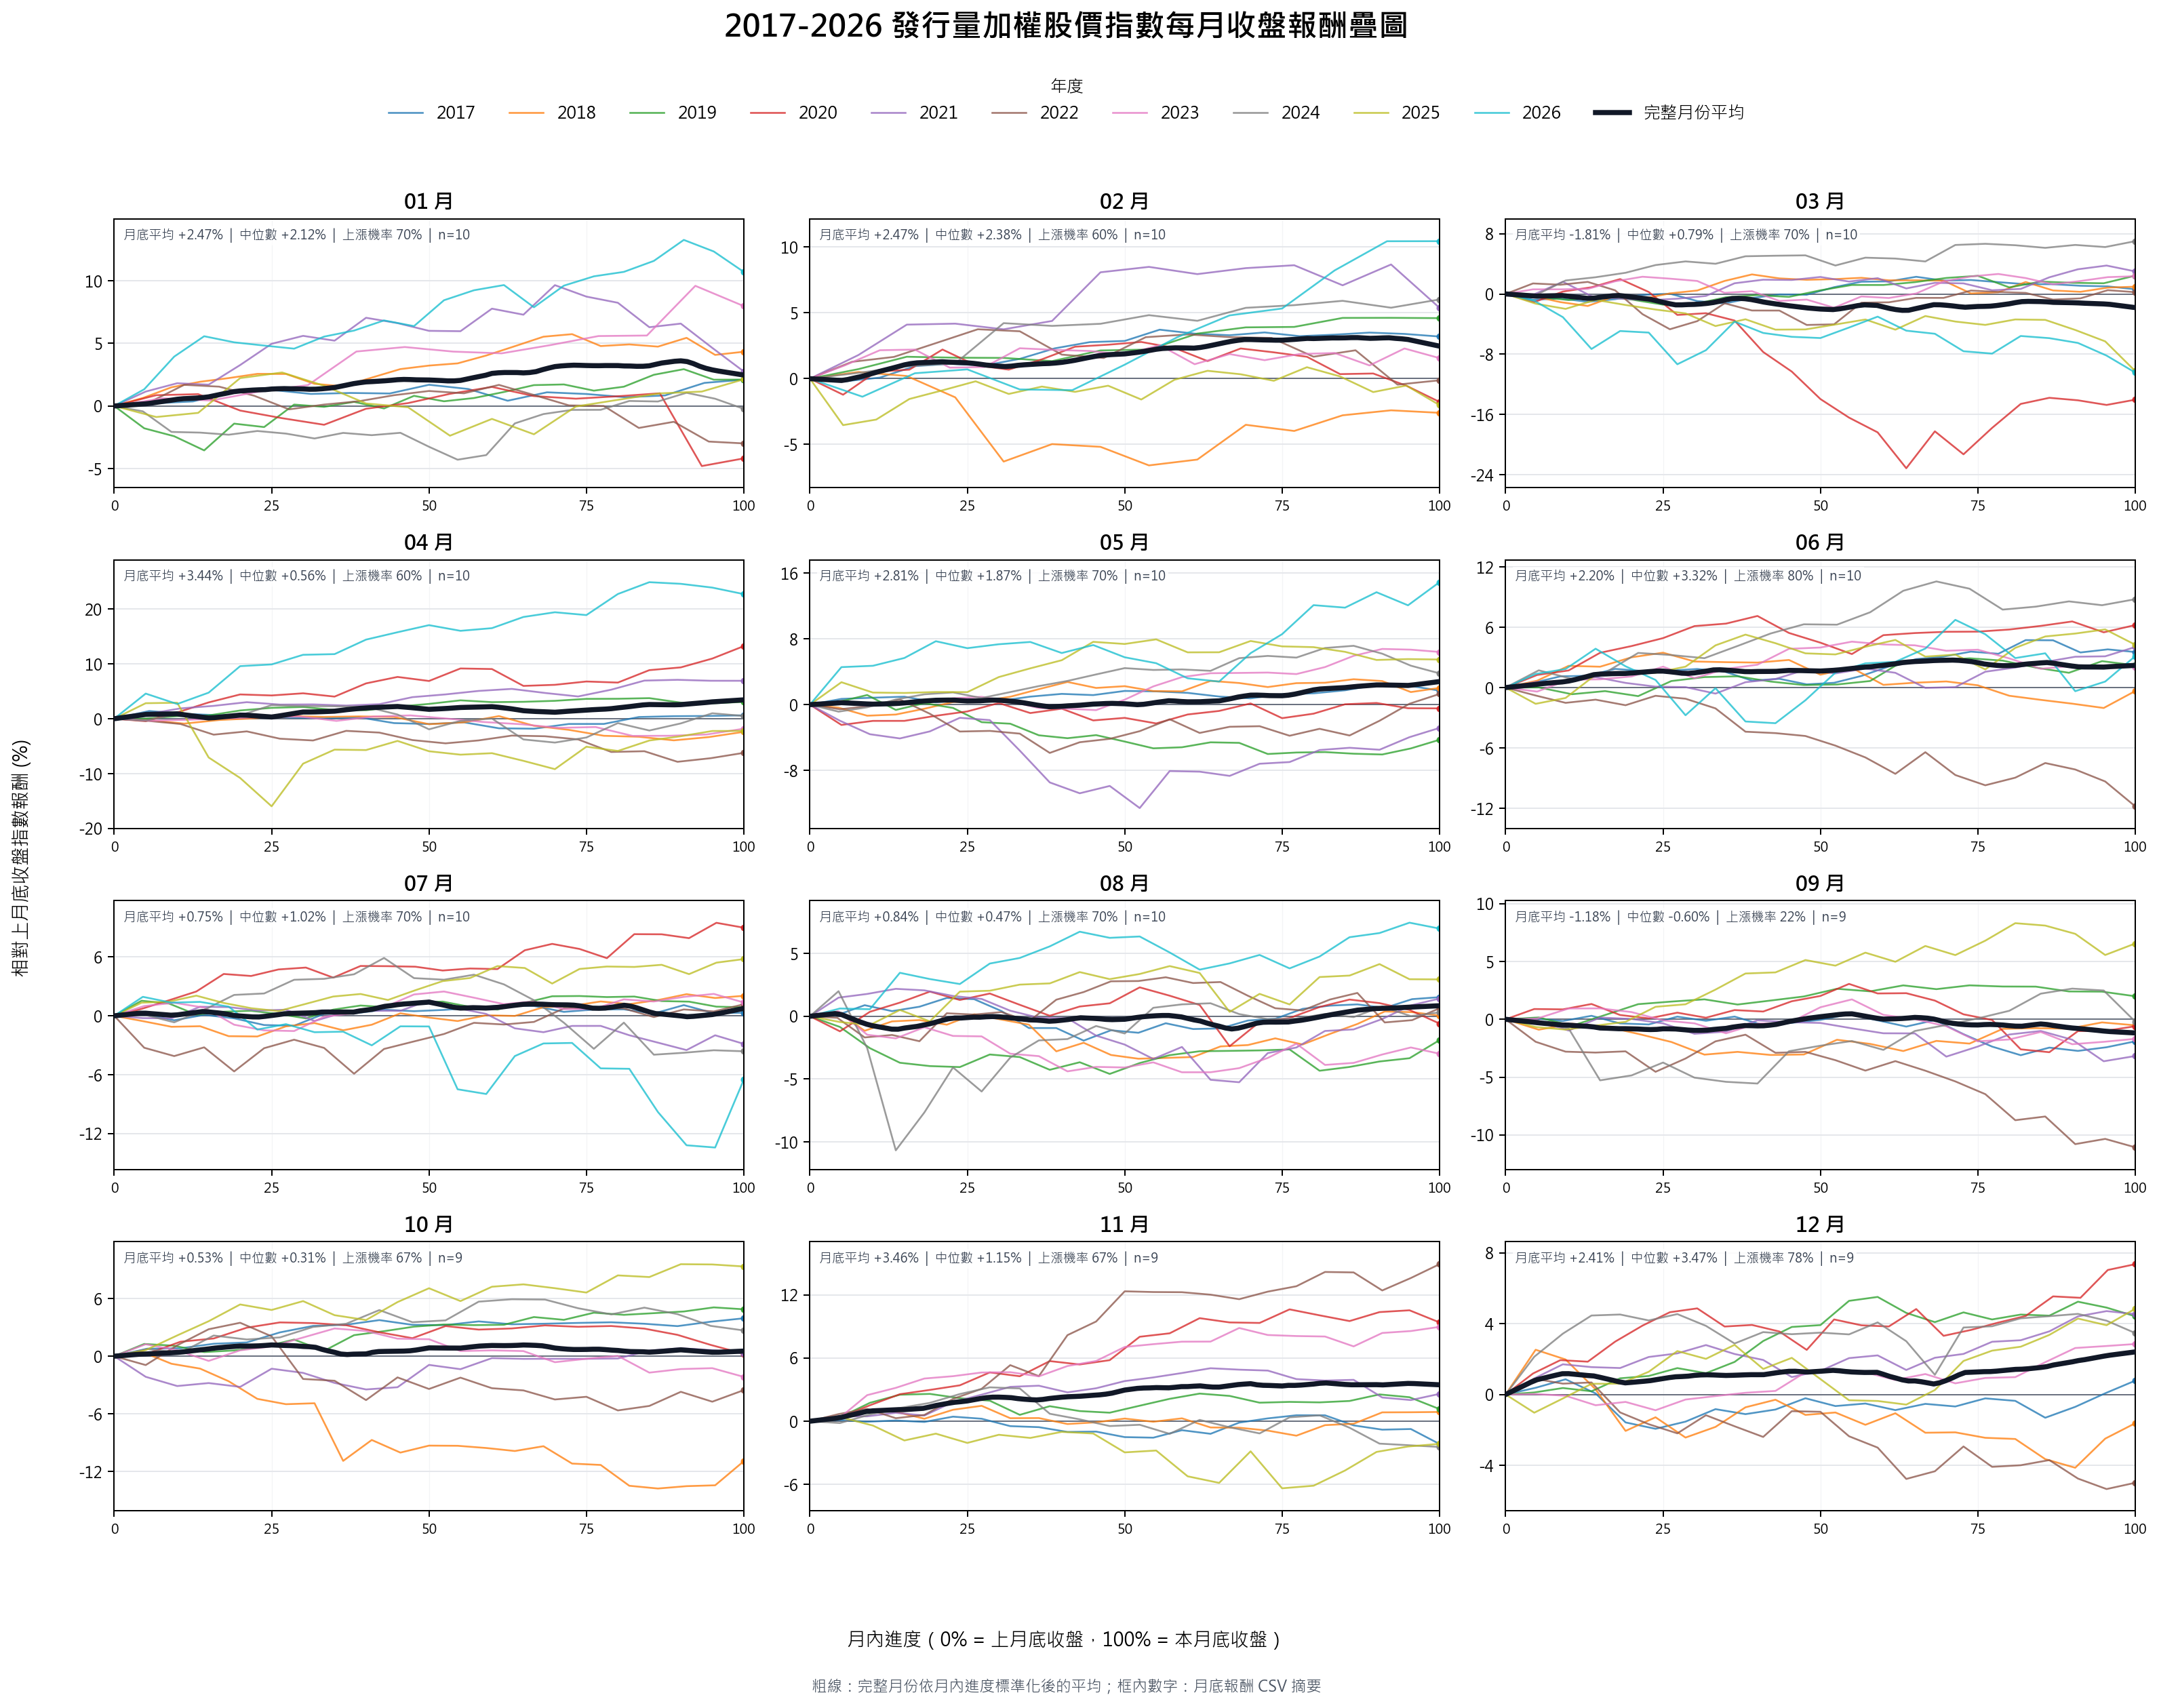

In [5]:
taiex_plot.plot_monthly_year_overlay(
    taiex_close,
    CHART_PATH,
    start_year=START_YEAR,
    end_year=END_YEAR,
)

from IPython.display import Image, display

print(f"Wrote: {CHART_PATH.resolve()}")
display(Image(filename=str(CHART_PATH)))

## Takeaways

- 正式月報酬取每個年月的最後有效收盤，除以上一個年月的最後有效收盤。
- 深色粗線代表完整月份的平均月內路徑，粗線在 100% 月內進度的終點等於圖內標示的月底平均報酬。
- 10 年季節性應同時看平均值與中位數；平均值容易被 2020 年 3 月、2026 年 4 月這類極端月份拉動。
- 上漲比例可補充穩定性。例如 6 月平均為正且完整月份中有 80% 上漲；9 月的平均、中位數與上漲比例則都偏弱。
- 目前年度尚未結束，因此後段月份只有 9 個完整觀測值；不完整月份不進入平均線與摘要。